# Multilingual Image Search

This example shows how [SentenceTransformers](https://www.sbert.net) can be used to map images and texts to the same vector space. 

As model, we use the [OpenAI CLIP Model](https://github.com/openai/CLIP), which was trained on a large set of images and image alt texts.  
The original CLIP Model only works for English, hence, we used [Multilingual Knowledge Distillation](https://huggingface.co/papers/2004.09813) to make this model work with 50+ languages.

Note that the CLIP is now from 2021 and more recent models exist. We use it for this illustration because it is small and therefore run on a Google Colab GPU.  
As an alternative, you can check the models with the [`zero-shot-image-classification`](https://huggingface.co/models?pipeline_tag=zero-shot-image-classification) pipeline tag on the 🤗 Hub.  
You can also test [trimmed](https://huggingface.co/blog/lbourdois/introduction-to-trimming) models that have the advantage of being smaller than the models from which they are derived while keeping the same performance. To find these models, we invite you to look at the `visual embedding` models listed in this [Space](https://huggingface.co/spaces/alphaedge-ai/Trimming_models_search).

As a source for fotos, we use the [Unsplash Dataset Lite](https://unsplash.com/data), which contains about 25k images. See the [License](https://unsplash.com/license) about the Unsplash images. 

Note: 25k images is rather small. If you search for really specific terms, the chance are high that no such photo exist in the collection.

In [1]:
from IPython.display import display
from PIL import Image

import torch

from datasets import load_dataset

from sentence_transformers import SentenceTransformer, util

In [ ]:
model = SentenceTransformer("sentence-transformers/clip-ViT-B-32-multilingual-v1")

In [3]:
# Next, we load the Unsplash Dataset Lite
unsplash = load_dataset("sentence-transformers/unsplash-lite")

# We can see that the dataset contains a column containing the images
# but also a column containing keywords that we will not use here.
unsplash

DatasetDict({
    train: Dataset({
        features: ['image', 'keywords'],
        num_rows: 24996
    })
})

In [4]:
# Now, we need to compute the embeddings
# The attached function will be required for the following cell
# in the case where precomputed embeddings are not used.
embeddings_name = "embeddings_clip-ViT-B-32" # #For embedding images, we need the non-multilingual CLIP model

def embed(batch):
    """
    adds to the dataset a column of embeddings of images calculated with the model
    """
    image = batch["image"]
    return {embeddings_name : model.encode(image, convert_to_tensor=True)}

In [5]:
# Here for the calculation of the embeddings, you have 2 choices:
# 1) `use_precomputed_embeddings = True` and in that case you can
# use embeddings that we have already pre-calculated in order to speed up
# the execution of the notebook.
# 2) `use_precomputed_embeddings = False` and compute the embeddings on the fly.
# Takes about 9 minutes on a Google Colab T4

use_precomputed_embeddings = True

if use_precomputed_embeddings:
    embeddings_ds = load_dataset("sentence-transformers/unsplash-lite", name=embeddings_name, split="train")
    unsplash["train"] = unsplash["train"].add_column(embeddings_name, embeddings_ds[embeddings_name])
    # We convert the embeddings into a Tensor Torch
    raw_embeddings = unsplash["train"][embeddings_name]
    img_emb = torch.tensor(raw_embeddings)

else:
    unsplash = unsplash.map(embed,batched=True,batch_size=16)

    # # Uncommented the rest of the else condition if you want to save the embeddings
    # # on the Hub to use `use_precomputed_embeddings = True` in the future

    # # We delete 'image' and 'keywords' so as not to save them as duplicates unnecessarily
    # embeddings_ds = unsplash['train'].remove_columns(['image', 'keywords'])
    # embeddings_ds.push_to_hub(
    #     "your_username/unsplash-lite", # your username
    #     config_name=embeddings_name,
    #     split="train",
    #     token="hf_xx" # your HF token
    # )

# We do have a new column containing our embeddings :D
unsplash

DatasetDict({
    train: Dataset({
        features: ['image', 'keywords', 'embeddings_clip-ViT-B-32'],
        num_rows: 24996
    })
})

In [6]:
# Next, we define a search function.
def search(query, k=3):
    # First, we encode the query (which can either be an image or a text string)
    query_emb = model.encode([query], convert_to_tensor=True, show_progress_bar=False)
    hits = util.semantic_search(query_emb, img_emb, top_k=k)[0]
    
    # Managing Query Display
    print("Query:")
    if isinstance(query, str):
        # If it's text, it's displayed normally
        print(f'"{query}"')
    elif isinstance(query, Image.Image):
        # If it's a PIL image, resize it so that it doesn't take up the entire screen
        query_display = query.copy()
        query_display.thumbnail((200, 200))
        display(query_display)
    else:
        # Default case in case
        display(query)

    
    for hit in hits:
        # Numerical index
        idx = hit['corpus_id']
        # Associated similarity score
        score = hit['score']
        print(f"Score: {score:.4f} (Index: {idx})")
        
        # We use the index to access the dataset
        image_data = unsplash["train"][idx]
        img = image_data["image"]
        
        # Rescaled to fit the screen
        width = 200
        height = int(width * img.height / img.width)
        display(img.resize((width, height)))

Query:
"Two dogs playing in the snow"
Score: 0.3285 (Index: 19459)


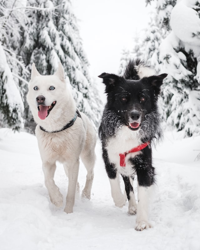

Score: 0.3214 (Index: 6267)


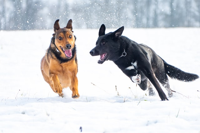

Score: 0.3147 (Index: 7186)


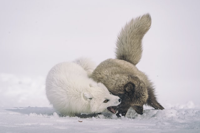

In [7]:
search("Two dogs playing in the snow")

Query:
"Eine Katze auf einem Stuhl"
Score: 0.3191 (Index: 5260)


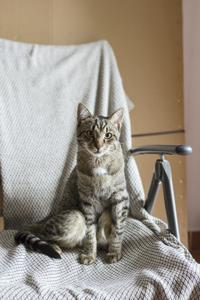

Score: 0.3160 (Index: 18991)


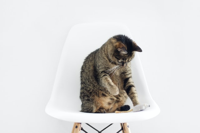

Score: 0.3109 (Index: 7337)


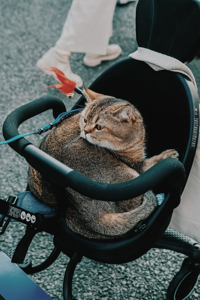

In [8]:
# German: A cat on a chair
search("Eine Katze auf einem Stuhl")

Query:
"Muchos peces"
Score: 0.3058 (Index: 6962)


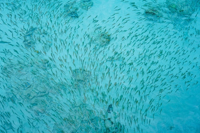

Score: 0.2916 (Index: 7559)


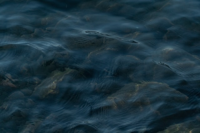

Score: 0.2896 (Index: 23691)


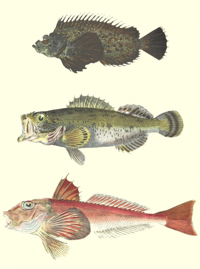

In [9]:
# Spanish: Many fish
search("Muchos peces")

Query:
"棕榈树的沙滩"
Score: 0.3235 (Index: 15950)


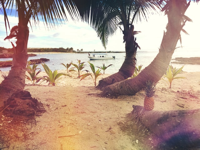

Score: 0.3228 (Index: 14499)


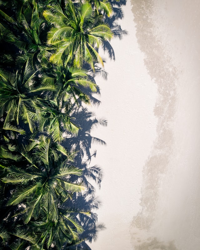

Score: 0.3197 (Index: 21756)


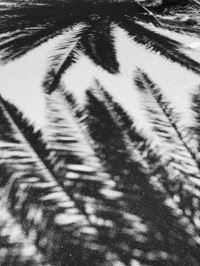

In [10]:
# Chinese: A beach with palm trees
search("棕榈树的沙滩")

Query:
"Закат на пляже"
Score: 0.3079 (Index: 7808)


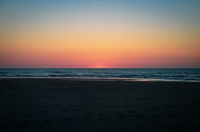

Score: 0.3058 (Index: 2709)


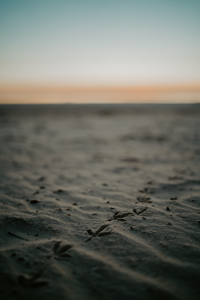

Score: 0.3039 (Index: 21658)


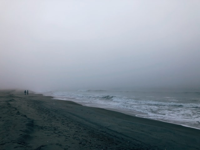

In [11]:
# Russian: A sunset on the beach
search("Закат на пляже")

Query:
"Parkta bir köpek"
Score: 0.2916 (Index: 2228)


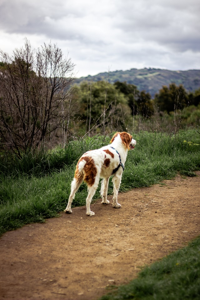

Score: 0.2911 (Index: 11064)


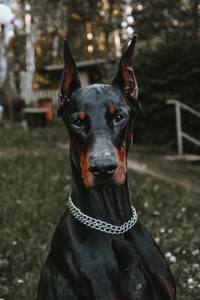

Score: 0.2893 (Index: 24200)


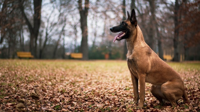

In [12]:
# Turkish: A dog in a park
search("Parkta bir köpek")

Query:
"夜のニューヨーク"
Score: 0.3130 (Index: 3789)


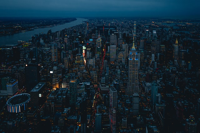

Score: 0.3061 (Index: 6303)


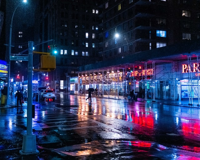

Score: 0.3054 (Index: 14117)


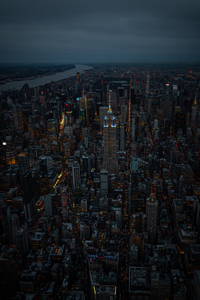

In [13]:
# Japanese: New York at night
search("夜のニューヨーク")